This file exists so I can determine the best way to adjust calibration curves day-to-day and temp-to-temp.

It serves no structural purpose.

In [5]:
# -----------------------------
# IMPORTS
# -----------------------------

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import odr, stats

plt.style.use("seaborn-v0_8-darkgrid")

In [6]:
# -----------------------------
# LOAD PEAK TABLE
# -----------------------------

csv_path = Path("peak_analysis_outputs/manual_peak_fits_all.csv")
df = pd.read_csv(csv_path)

print("Rows loaded:", len(df))
display(df.head())

Rows loaded: 138


,file,group_id,peak_in_group,n_peaks_in_group,theoretical_energy_keV,theoretical_energy_keV_err,clicked_center_ADC,center_ADC,center_ADC_err,sigma_ADC,sigma_ADC_err,amplitude_counts_per_s,amplitude_counts_per_s_err,gaussian_area_counts,fit_xmin,fit_xmax,background_slope,background_intercept
0,calibration/daily/Co60_21.9C_preamp100_mar5.csv,1,1,2,1173.228,0.003,652,649.075865,0.223619,14.749785,0.297055,5.958860,0.087479,220.312327,597,792,-0.005121,3.997337
1,calibration/daily/Co60_21.9C_preamp100_mar5.csv,1,2,2,1332.494,0.002,732,734.205555,0.282125,16.329201,0.369967,5.032531,0.083152,205.987725,597,792,-0.005121,3.997337
2,calibration/daily/Co60_22.4C_preamp100_feb26.csv,1,1,2,1173.228,0.003,652,651.142231,0.184083,14.864290,0.239054,14.550275,0.172824,542.132295,596,815,-0.011299,9.124645
3,calibration/daily/Co60_22.4C_preamp100_feb26.csv,1,2,2,1332.494,0.002,740,737.334233,0.229609,16.270415,0.269837,12.265332,0.158176,500.227869,596,815,-0.011299,9.124645
4,calibration/daily/Co60_22.5C_preamp100_mar3.csv,1,1,2,1173.228,0.003,645,648.684317,0.222826,14.592461,0.292220,4.466219,0.065576,163.364814,596,790,-0.003907,3.043445


In [7]:
# -----------------------------
# PARSE DATE / TEMP / PREAMP / ISOTOPE
# -----------------------------

def parse_metadata(file_string):
    s = str(file_string).lower()

    # date label
    day = None
    for tag in ["feb24", "feb25", "feb26", "mar3", "mar5"]:
        if tag in s:
            day = tag
            break

    # temperature
    temp_C = np.nan
    m = re.search(r'_(\d+(?:\.\d+)?)c', s)
    if m:
        temp_C = float(m.group(1))

    # preamp
    preamp = np.nan
    m = re.search(r'preamp[_]?(\d+)', s)
    if m:
        preamp = int(m.group(1))

    # isotope
    isotope = None
    if "co60" in s or "/co_" in s:
        isotope = "Co60"
    elif "cs" in s:
        isotope = "Cs137"
    elif "ba" in s:
        isotope = "Ba"
    elif "na" in s:
        isotope = "Na22"
    elif "co57" in s:
        isotope = "Co57"

    return pd.Series({
        "day": day,
        "temp_C": temp_C,
        "preamp": preamp,
        "isotope": isotope
    })

meta = df["file"].apply(parse_metadata)
df = pd.concat([df, meta], axis=1)

display(df[["file", "day", "temp_C", "preamp", "isotope"]].head(10))

,file,day,temp_C,preamp,isotope
0,calibration/daily/Co60_21.9C_preamp100_mar5.csv,mar5,21.9,100.0,Co60
1,calibration/daily/Co60_21.9C_preamp100_mar5.csv,mar5,21.9,100.0,Co60
2,calibration/daily/Co60_22.4C_preamp100_feb26.csv,feb26,22.4,100.0,Co60
3,calibration/daily/Co60_22.4C_preamp100_feb26.csv,feb26,22.4,100.0,Co60
4,calibration/daily/Co60_22.5C_preamp100_mar3.csv,mar3,22.5,100.0,Co60
5,calibration/daily/Co60_22.5C_preamp100_mar3.csv,mar3,22.5,100.0,Co60
6,calibration/daily/Cs_21.9C_preamp0_mar5.csv,mar5,21.9,0.0,Cs137
7,calibration/daily/Cs_21.9C_preamp0_mar5.csv,mar5,21.9,0.0,Cs137
8,calibration/daily/Cs_21.9C_preamp0_mar5.csv,mar5,21.9,0.0,Cs137
9,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,22.0,0.0,Cs137


In [8]:
# -----------------------------
# DAILY CALIBRATION ROWS
# -----------------------------

daily = df[df["file"].str.contains("calibration/daily", na=False)].copy()
daily = daily.dropna(subset=["theoretical_energy_keV", "center_ADC", "center_ADC_err"])

print("Daily calibration rows:", len(daily))

display(
    daily[[
        "file",
        "day",
        "temp_C",
        "preamp",
        "isotope",
        "peak_in_group",
        "center_ADC",
        "center_ADC_err",
        "theoretical_energy_keV",
        "theoretical_energy_keV_err"
    ]].sort_values(["day", "preamp", "file", "center_ADC"])
)

Daily calibration rows: 14


,file,day,temp_C,preamp,isotope,peak_in_group,center_ADC,center_ADC_err,theoretical_energy_keV,theoretical_energy_keV_err
12,calibration/daily/Cs_22.4C_preamp0_feb26.csv,feb26,22.4,0.0,Cs137,1,503.121706,0.164891,661.657,0.003000
13,calibration/daily/Cs_22.4C_preamp0_feb26.csv,feb26,22.4,0.0,Cs137,1,994.927700,4.064987,1323.314,0.004243
2,calibration/daily/Co60_22.4C_preamp100_feb26.csv,feb26,22.4,100.0,Co60,1,651.142231,0.184083,1173.228,0.003000
3,calibration/daily/Co60_22.4C_preamp100_feb26.csv,feb26,22.4,100.0,Co60,2,737.334233,0.229609,1332.494,0.002000
9,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,22.0,0.0,Cs137,1,27.296657,0.088789,34.550,2.750000
10,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,22.0,0.0,Cs137,1,505.671076,0.183272,661.657,0.003000
11,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,22.0,0.0,Cs137,1,987.346319,3.723048,1323.314,0.004243
4,calibration/daily/Co60_22.5C_preamp100_mar3.csv,mar3,22.5,100.0,Co60,1,648.684317,0.222826,1173.228,0.003000
5,calibration/daily/Co60_22.5C_preamp100_mar3.csv,mar3,22.5,100.0,Co60,2,733.687508,0.285650,1332.494,0.002000
6,calibration/daily/Cs_21.9C_preamp0_mar5.csv,mar5,21.9,0.0,Cs137,1,26.398970,0.214316,34.550,2.750000


In [9]:
# -----------------------------
# BASE FITS (FEB 24)
# -----------------------------

feb24 = df[df["file"].str.contains("calibration/feb_24", na=False)].copy()
feb24 = feb24.dropna(subset=["theoretical_energy_keV", "center_ADC", "center_ADC_err"])

# fill any missing theory errors conservatively
feb24["theoretical_energy_keV_err"] = feb24["theoretical_energy_keV_err"].fillna(0.01)

base0 = feb24[feb24["preamp"] == 0].copy()
base100 = feb24[feb24["preamp"] == 100].copy()

def linear_model(B, x):
    m, b = B
    return m * x + b

def fit_odr_linear(data):
    x = data["center_ADC"].to_numpy(float)
    sx = data["center_ADC_err"].to_numpy(float)
    y = data["theoretical_energy_keV"].to_numpy(float)
    sy = data["theoretical_energy_keV_err"].to_numpy(float)

    model = odr.Model(linear_model)
    realdata = odr.RealData(x, y, sx=sx, sy=sy)
    fit = odr.ODR(realdata, model, beta0=[1.0, 0.0]).run()
    return fit

fit0 = fit_odr_linear(base0)
fit100 = fit_odr_linear(base100)

print("BASE FIT — PREAMP 0")
print("m =", fit0.beta[0], "+/-", fit0.sd_beta[0])
print("b =", fit0.beta[1], "+/-", fit0.sd_beta[1])

print()
print("BASE FIT — PREAMP 100")
print("m =", fit100.beta[0], "+/-", fit100.sd_beta[0])
print("b =", fit100.beta[1], "+/-", fit100.sd_beta[1])

BASE FIT — PREAMP 0
m = 1.317572044272962 +/- 0.004624026369464607
b = -3.916731068524743 +/- 2.043277475970123

BASE FIT — PREAMP 100
m = 1.8572043077402383 +/- 0.003202017076929638
b = -37.594183111644995 +/- 1.122961837051316


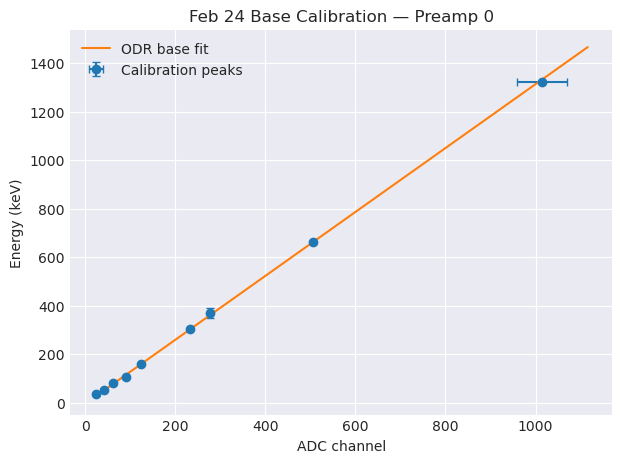

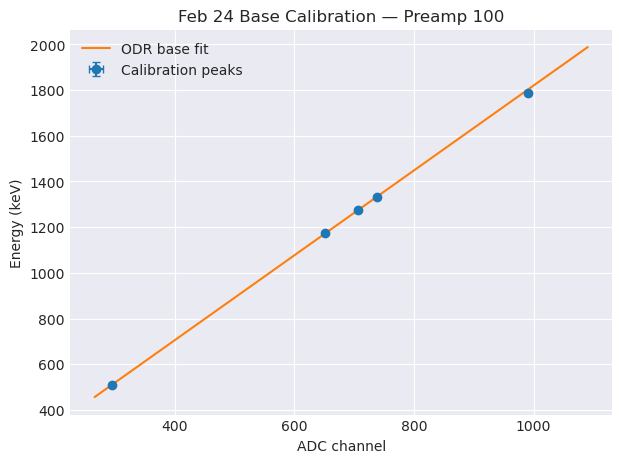

In [10]:
# -----------------------------
# PLOT BASE FITS
# -----------------------------

def plot_base_fit(data, fit, title):
    x = data["center_ADC"].to_numpy(float)
    sx = data["center_ADC_err"].to_numpy(float)
    y = data["theoretical_energy_keV"].to_numpy(float)
    sy = data["theoretical_energy_keV_err"].to_numpy(float)

    xx = np.linspace(0.9 * x.min(), 1.1 * x.max(), 500)
    yy = linear_model(fit.beta, xx)

    plt.figure(figsize=(7, 5))
    plt.errorbar(x, y, xerr=sx, yerr=sy, fmt="o", capsize=3, label="Calibration peaks")
    plt.plot(xx, yy, label="ODR base fit")
    plt.xlabel("ADC channel")
    plt.ylabel("Energy (keV)")
    plt.title(title)
    plt.legend()
    plt.show()

plot_base_fit(base0, fit0, "Feb 24 Base Calibration — Preamp 0")
plot_base_fit(base100, fit100, "Feb 24 Base Calibration — Preamp 100")

In [11]:
# -----------------------------
# DAILY ADC SHIFTS RELATIVE TO BASE
# -----------------------------

def get_base_params(preamp):
    if preamp == 0:
        return fit0.beta[0], fit0.beta[1]
    elif preamp == 100:
        return fit100.beta[0], fit100.beta[1]
    else:
        raise ValueError(f"Unexpected preamp value: {preamp}")

def predicted_adc_from_base(E, preamp):
    m, b = get_base_params(preamp)
    return (E - b) / m

def predicted_adc_err_from_base(E_err, preamp):
    m, _ = get_base_params(preamp)
    return abs(E_err / m)

daily["theoretical_energy_keV_err"] = daily["theoretical_energy_keV_err"].fillna(0.01)

daily["adc_pred_base"] = daily.apply(
    lambda r: predicted_adc_from_base(r["theoretical_energy_keV"], r["preamp"]),
    axis=1
)

daily["adc_pred_base_err"] = daily.apply(
    lambda r: predicted_adc_err_from_base(r["theoretical_energy_keV_err"], r["preamp"]),
    axis=1
)

daily["adc_shift_vs_base"] = daily["center_ADC"] - daily["adc_pred_base"]

daily["adc_shift_vs_base_err"] = np.sqrt(
    daily["center_ADC_err"]**2 + daily["adc_pred_base_err"]**2
)

display(
    daily[[
        "file",
        "day",
        "temp_C",
        "preamp",
        "isotope",
        "theoretical_energy_keV",
        "center_ADC",
        "adc_pred_base",
        "adc_shift_vs_base",
        "adc_shift_vs_base_err"
    ]].sort_values(["day", "preamp", "theoretical_energy_keV"])
)

,file,day,temp_C,preamp,isotope,theoretical_energy_keV,center_ADC,adc_pred_base,adc_shift_vs_base,adc_shift_vs_base_err
12,calibration/daily/Cs_22.4C_preamp0_feb26.csv,feb26,22.4,0.0,Cs137,661.657,503.121706,505.151680,-2.029973,0.164907
13,calibration/daily/Cs_22.4C_preamp0_feb26.csv,feb26,22.4,0.0,Cs137,1323.314,994.927700,1007.330671,-12.402971,4.064988
2,calibration/daily/Co60_22.4C_preamp100_feb26.csv,feb26,22.4,100.0,Co60,1173.228,651.142231,651.959603,-0.817372,0.184091
3,calibration/daily/Co60_22.4C_preamp100_feb26.csv,feb26,22.4,100.0,Co60,1332.494,737.334233,737.715381,-0.381148,0.229612
9,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,22.0,0.0,Cs137,34.550,27.296657,29.195163,-1.898506,2.089060
10,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,22.0,0.0,Cs137,661.657,505.671076,505.151680,0.519397,0.183286
11,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,22.0,0.0,Cs137,1323.314,987.346319,1007.330671,-19.984352,3.723049
4,calibration/daily/Co60_22.5C_preamp100_mar3.csv,mar3,22.5,100.0,Co60,1173.228,648.684317,651.959603,-3.275286,0.222832
5,calibration/daily/Co60_22.5C_preamp100_mar3.csv,mar3,22.5,100.0,Co60,1332.494,733.687508,737.715381,-4.027873,0.285652
6,calibration/daily/Cs_21.9C_preamp0_mar5.csv,mar5,21.9,0.0,Cs137,34.550,26.398970,29.195163,-2.796193,2.098147


In [12]:
# -----------------------------
# QUALITY TIERS FOR DAILY PEAKS
# -----------------------------

def classify_daily_peak(row):
    E = row["theoretical_energy_keV"]
    iso = row["isotope"]
    preamp = row["preamp"]

    # strongest anchors
    if preamp == 100 and iso == "Co60" and np.isclose(E, 1173.228, atol=1.0):
        return "primary"
    if preamp == 100 and iso == "Co60" and np.isclose(E, 1332.494, atol=1.0):
        return "primary"
    if preamp == 0 and iso == "Cs137" and np.isclose(E, 661.657, atol=1.0):
        return "primary"

    # weaker / diagnostic anchors
    if preamp == 0 and iso == "Cs137" and np.isclose(E, 34.55, atol=2.0):
        return "secondary"
    if preamp == 0 and iso == "Cs137" and np.isclose(E, 1323.314, atol=2.0):
        return "secondary"

    return "other"

daily["quality_tier"] = daily.apply(classify_daily_peak, axis=1)

display(
    daily[[
        "file",
        "day",
        "preamp",
        "isotope",
        "theoretical_energy_keV",
        "center_ADC_err",
        "adc_shift_vs_base",
        "adc_shift_vs_base_err",
        "quality_tier"
    ]].sort_values(["day", "preamp", "theoretical_energy_keV"])
)

,file,day,preamp,isotope,theoretical_energy_keV,center_ADC_err,adc_shift_vs_base,adc_shift_vs_base_err,quality_tier
12,calibration/daily/Cs_22.4C_preamp0_feb26.csv,feb26,0.0,Cs137,661.657,0.164891,-2.029973,0.164907,primary
13,calibration/daily/Cs_22.4C_preamp0_feb26.csv,feb26,0.0,Cs137,1323.314,4.064987,-12.402971,4.064988,secondary
2,calibration/daily/Co60_22.4C_preamp100_feb26.csv,feb26,100.0,Co60,1173.228,0.184083,-0.817372,0.184091,primary
3,calibration/daily/Co60_22.4C_preamp100_feb26.csv,feb26,100.0,Co60,1332.494,0.229609,-0.381148,0.229612,primary
9,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,0.0,Cs137,34.550,0.088789,-1.898506,2.089060,secondary
10,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,0.0,Cs137,661.657,0.183272,0.519397,0.183286,primary
11,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,0.0,Cs137,1323.314,3.723048,-19.984352,3.723049,secondary
4,calibration/daily/Co60_22.5C_preamp100_mar3.csv,mar3,100.0,Co60,1173.228,0.222826,-3.275286,0.222832,primary
5,calibration/daily/Co60_22.5C_preamp100_mar3.csv,mar3,100.0,Co60,1332.494,0.285650,-4.027873,0.285652,primary
6,calibration/daily/Cs_21.9C_preamp0_mar5.csv,mar5,0.0,Cs137,34.550,0.214316,-2.796193,2.098147,secondary


In [13]:
# -----------------------------
# SHIFT-ONLY DAILY CORRECTIONS
# -----------------------------

def weighted_mean(x, sx):
    w = 1.0 / sx**2
    mu = np.sum(w * x) / np.sum(w)
    smu = np.sqrt(1.0 / np.sum(w))
    return mu, smu

shift_rows = []

for (day, preamp), sub in daily[daily["quality_tier"] == "primary"].groupby(["day", "preamp"]):
    dx = sub["adc_shift_vs_base"].to_numpy(float)
    sdx = sub["adc_shift_vs_base_err"].to_numpy(float)

    shift_adc, shift_adc_err = weighted_mean(dx, sdx)

    shift_rows.append({
        "day": day,
        "preamp": preamp,
        "n_primary_points": len(sub),
        "daily_shift_adc": shift_adc,
        "daily_shift_adc_err": shift_adc_err,
        "temp_C_mean": sub["temp_C"].mean()
    })

shift_df = pd.DataFrame(shift_rows).sort_values(["day", "preamp"])

display(shift_df)

,day,preamp,n_primary_points,daily_shift_adc,daily_shift_adc_err,temp_C_mean
0,feb26,0.0,1,-2.029973,0.164907,22.4
1,feb26,100.0,2,-0.646685,0.143628,22.4
2,mar3,0.0,1,0.519397,0.183286,22.0
3,mar3,100.0,2,-3.560000,0.175696,22.5
4,mar5,0.0,1,0.027958,0.180245,21.9
5,mar5,100.0,2,-3.125317,0.175249,21.9


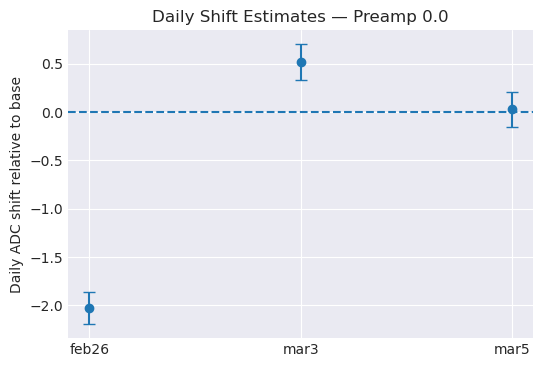

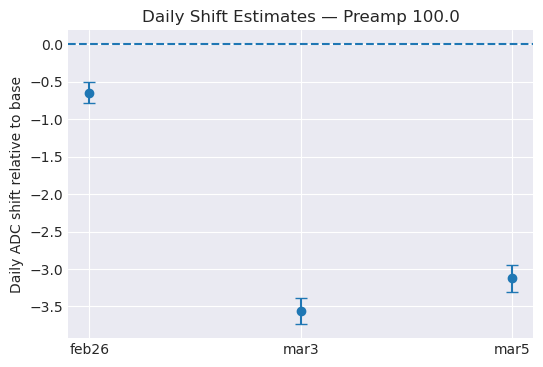

In [14]:
# -----------------------------
# PLOT DAILY SHIFT ESTIMATES
# -----------------------------

for preamp_value in sorted(shift_df["preamp"].unique()):
    sub = shift_df[shift_df["preamp"] == preamp_value].copy()

    plt.figure(figsize=(6, 4))
    plt.errorbar(
        sub["day"],
        sub["daily_shift_adc"],
        yerr=sub["daily_shift_adc_err"],
        fmt="o",
        capsize=4
    )
    plt.axhline(0, linestyle="--")
    plt.ylabel("Daily ADC shift relative to base")
    plt.title(f"Daily Shift Estimates — Preamp {preamp_value}")
    plt.show()

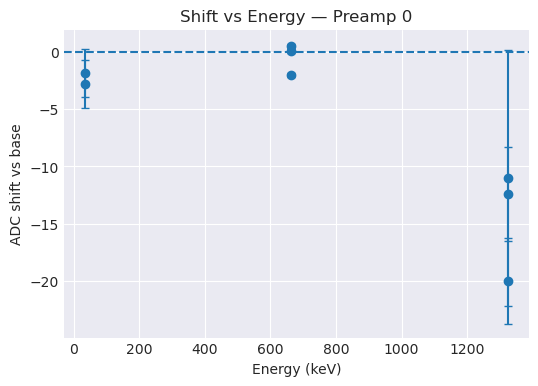

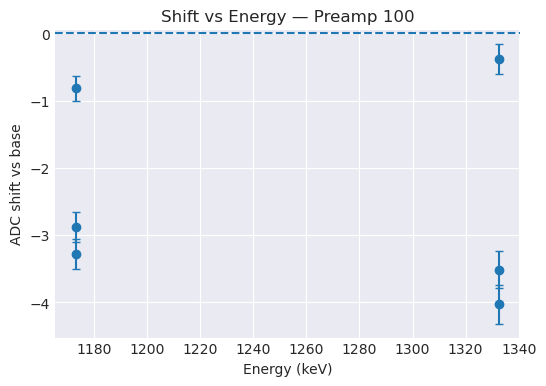

In [15]:
# -----------------------------
# DOES DRIFT LOOK LIKE PURE TRANSLATION?
# -----------------------------
# If the base-corrected ADC shifts do not depend strongly on energy,
# then shift-only is probably sufficient.

for preamp_value in sorted(daily["preamp"].dropna().unique()):
    sub = daily[daily["preamp"] == preamp_value].copy()

    plt.figure(figsize=(6, 4))
    plt.errorbar(
        sub["theoretical_energy_keV"],
        sub["adc_shift_vs_base"],
        yerr=sub["adc_shift_vs_base_err"],
        fmt="o",
        capsize=3
    )
    plt.axhline(0, linestyle="--")
    plt.xlabel("Energy (keV)")
    plt.ylabel("ADC shift vs base")
    plt.title(f"Shift vs Energy — Preamp {int(preamp_value)}")
    plt.show()

In [16]:
# -----------------------------
# DAILY AFFINE RE-FITS (COMPARISON MODEL)
# -----------------------------

affine_rows = []

for (day, preamp), sub in daily.groupby(["day", "preamp"]):
    # need at least 2 points to fit
    if len(sub) < 2:
        continue

    x = sub["center_ADC"].to_numpy(float)
    sx = sub["center_ADC_err"].to_numpy(float)
    y = sub["theoretical_energy_keV"].to_numpy(float)
    sy = sub["theoretical_energy_keV_err"].fillna(0.01).to_numpy(float)

    try:
        model = odr.Model(linear_model)
        realdata = odr.RealData(x, y, sx=sx, sy=sy)
        fit = odr.ODR(realdata, model, beta0=[1.0, 0.0]).run()

        affine_rows.append({
            "day": day,
            "preamp": preamp,
            "n_points": len(sub),
            "m_day": fit.beta[0],
            "m_day_err": fit.sd_beta[0],
            "b_day": fit.beta[1],
            "b_day_err": fit.sd_beta[1]
        })

    except Exception as e:
        print(f"Could not fit {day}, preamp {preamp}: {e}")

affine_df = pd.DataFrame(affine_rows).sort_values(["day", "preamp"])
display(affine_df)

,day,preamp,n_points,m_day,m_day_err,b_day,b_day_err
0,feb26,0.0,2,1.345362,1.243718e-41,-15.223728,6.272330e-39
1,feb26,100.0,2,1.847805,4.781833e-13,-29.955788,3.281093e-10
2,mar3,0.0,3,1.326466,2.649374e-02,-8.986436,1.339057e+01
3,mar3,100.0,2,1.873647,6.898886e-41,-42.177620,4.705658e-38
4,mar5,0.0,3,1.311211,7.013825e-03,-0.730632,3.531571e+00
5,mar5,100.0,2,1.870863,0.000000e+00,-41.104107,0.000000e+00


In [17]:
# -----------------------------
# SLOPE COMPARISON
# -----------------------------

base_slopes = {
    0: (fit0.beta[0], fit0.sd_beta[0]),
    100: (fit100.beta[0], fit100.sd_beta[0])
}

comparison_rows = []

for _, row in affine_df.iterrows():
    preamp = row["preamp"]
    m_base, sm_base = base_slopes[preamp]

    delta_m = row["m_day"] - m_base
    s_delta_m = np.sqrt(row["m_day_err"]**2 + sm_base**2)

    comparison_rows.append({
        "day": row["day"],
        "preamp": preamp,
        "m_base": m_base,
        "m_day": row["m_day"],
        "delta_m": delta_m,
        "delta_m_sigma": delta_m / s_delta_m if s_delta_m > 0 else np.nan
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(["day", "preamp"])
display(comparison_df)

,day,preamp,m_base,m_day,delta_m,delta_m_sigma
0,feb26,0.0,1.317572,1.345362,0.027790,6.009863
1,feb26,100.0,1.857204,1.847805,-0.009399,-2.935473
2,mar3,0.0,1.317572,1.326466,0.008894,0.330697
3,mar3,100.0,1.857204,1.873647,0.016443,5.135198
4,mar5,0.0,1.317572,1.311211,-0.006361,-0.757180
5,mar5,100.0,1.857204,1.870863,0.013659,4.265695


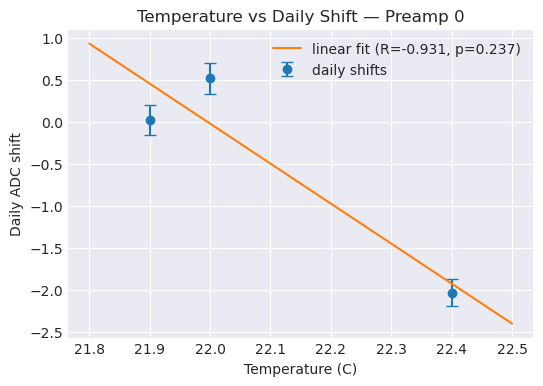

Preamp 0
  slope = -4.7609 ADC/C
  R = -0.9313
  p = 0.2373



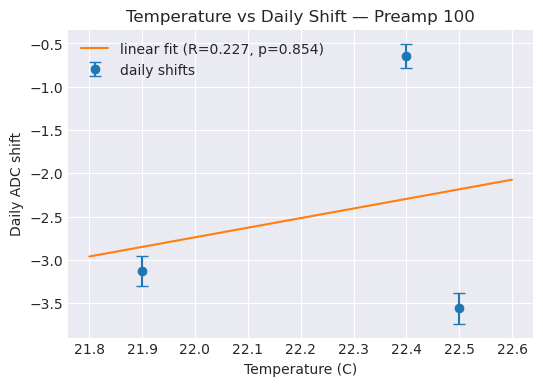

Preamp 100
  slope = 1.1083 ADC/C
  R = 0.2267
  p = 0.8544



In [18]:
# -----------------------------
# TEMPERATURE DEPENDENCE OF DAILY SHIFT
# -----------------------------

for preamp_value in sorted(shift_df["preamp"].unique()):
    sub = shift_df[shift_df["preamp"] == preamp_value].copy()

    if len(sub) < 2:
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        sub["temp_C_mean"], sub["daily_shift_adc"]
    )

    plt.figure(figsize=(6, 4))
    plt.errorbar(
        sub["temp_C_mean"],
        sub["daily_shift_adc"],
        yerr=sub["daily_shift_adc_err"],
        fmt="o",
        capsize=4,
        label="daily shifts"
    )

    xfit = np.linspace(sub["temp_C_mean"].min() - 0.1, sub["temp_C_mean"].max() + 0.1, 200)
    yfit = slope * xfit + intercept
    plt.plot(xfit, yfit, label=f"linear fit (R={r_value:.3f}, p={p_value:.3g})")

    plt.xlabel("Temperature (C)")
    plt.ylabel("Daily ADC shift")
    plt.title(f"Temperature vs Daily Shift — Preamp {int(preamp_value)}")
    plt.legend()
    plt.show()

    print(f"Preamp {int(preamp_value)}")
    print(f"  slope = {slope:.4f} ADC/C")
    print(f"  R = {r_value:.4f}")
    print(f"  p = {p_value:.4g}")
    print()

In [19]:
# -----------------------------
# MODEL-SELECTION SUMMARY
# -----------------------------

summary_rows = []

for preamp_value in sorted(daily["preamp"].dropna().unique()):
    sub = daily[daily["preamp"] == preamp_value].copy()

    # base-only residuals in ADC space
    base_wrss = np.sum((sub["adc_shift_vs_base"] / sub["adc_shift_vs_base_err"])**2)

    summary_rows.append({
        "preamp": int(preamp_value),
        "model": "base_only",
        "weighted_residual_sum": base_wrss
    })

    # shift-only residuals
    for day in sub["day"].dropna().unique():
        day_sub = sub[sub["day"] == day].copy()
        shift_sub = shift_df[(shift_df["preamp"] == preamp_value) & (shift_df["day"] == day)]

        if len(shift_sub) == 1:
            shift_val = shift_sub.iloc[0]["daily_shift_adc"]
            resid = day_sub["adc_shift_vs_base"] - shift_val
            wrss = np.sum((resid / day_sub["adc_shift_vs_base_err"])**2)

            summary_rows.append({
                "preamp": int(preamp_value),
                "model": f"shift_only_{day}",
                "weighted_residual_sum": wrss
            })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.sort_values(["preamp", "model"]))

,preamp,model,weighted_residual_sum
0,0,base_only,201.289903
3,0,shift_only_feb26,6.511634
2,0,shift_only_mar3,31.669360
1,0,shift_only_mar5,2.796882
4,100,base_only,758.403229
6,100,shift_only_feb26,2.197080
7,100,shift_only_mar3,4.315296
5,100,shift_only_mar5,3.024493


In [20]:
# # -----------------------------
# # PREAMP100 Co-60 PRIMARY PAIRS
# # -----------------------------

# co60_100 = daily[
#     (daily["preamp"] == 100) &
#     (daily["isotope"] == "Co60") &
#     (daily["quality_tier"] == "primary")
# ].copy()

# display(co60_100[[
#     "day",
#     "theoretical_energy_keV",
#     "adc_shift_vs_base",
#     "adc_shift_vs_base_err"
# ]].sort_values(["day", "theoretical_energy_keV"]))

,day,theoretical_energy_keV,adc_shift_vs_base,adc_shift_vs_base_err
2,feb26,1173.228,-0.817372,0.184091
3,feb26,1332.494,-0.381148,0.229612
4,mar3,1173.228,-3.275286,0.222832
5,mar3,1332.494,-4.027873,0.285652
0,mar5,1173.228,-2.883738,0.223625
1,mar5,1332.494,-3.509825,0.282127


In [21]:
# # -----------------------------
# # SAME-DAY Co-60 DIFFERENCES
# # -----------------------------

# pair_rows = []

# for day, sub in co60_100.groupby("day"):
#     sub = sub.sort_values("theoretical_energy_keV").copy()
#     if len(sub) != 2:
#         continue

#     r1 = sub.iloc[0]
#     r2 = sub.iloc[1]

#     delta = r1["adc_shift_vs_base"] - r2["adc_shift_vs_base"]
#     var_formal = r1["adc_shift_vs_base_err"]**2 + r2["adc_shift_vs_base_err"]**2

#     pair_rows.append({
#         "day": day,
#         "E1_keV": r1["theoretical_energy_keV"],
#         "E2_keV": r2["theoretical_energy_keV"],
#         "delta_shift_adc": delta,
#         "abs_delta_shift_adc": abs(delta),
#         "var_formal": var_formal,
#         "sigma_formal": np.sqrt(var_formal)
#     })

# pair_df = pd.DataFrame(pair_rows).sort_values("day")
# display(pair_df)

,day,E1_keV,E2_keV,delta_shift_adc,abs_delta_shift_adc,var_formal,sigma_formal
0,feb26,1173.228,1332.494,-0.436223,0.436223,0.086611,0.294297
1,mar3,1173.228,1332.494,0.752586,0.752586,0.131251,0.362286
2,mar5,1173.228,1332.494,0.626087,0.626087,0.129604,0.360005


In [22]:
# # -----------------------------
# # MOMENT ESTIMATE OF TAU
# # -----------------------------

# mean_delta2 = np.mean(pair_df["delta_shift_adc"]**2)
# mean_var_formal = np.mean(pair_df["var_formal"])

# tau2_moment = max(0.0, 0.5 * (mean_delta2 - mean_var_formal))
# tau_moment = np.sqrt(tau2_moment)

# print("mean(delta^2) =", mean_delta2)
# print("mean(formal variance) =", mean_var_formal)
# print("tau_moment =", tau_moment, "ADC channels")

mean(delta^2) = 0.38288748195675676
mean(formal variance) = 0.11582176175920417
tau_moment = 0.365421482809613 ADC channels


In [23]:
# # -----------------------------
# # MLE ESTIMATE OF TAU
# # -----------------------------

# from scipy.optimize import minimize_scalar

# delta_vals = pair_df["delta_shift_adc"].to_numpy(float)
# var_formal_vals = pair_df["var_formal"].to_numpy(float)

# def neg_loglike_tau(tau):
#     if tau < 0:
#         return np.inf
#     V = var_formal_vals + 2.0 * tau**2
#     return 0.5 * np.sum(np.log(V) + delta_vals**2 / V)

# res = minimize_scalar(neg_loglike_tau, bounds=(0, 5), method="bounded")
# tau_mle = res.x

# print("tau_mle =", tau_mle, "ADC channels")
# print("optimization success:", res.success)

tau_mle = 0.35576723244521313 ADC channels
optimization success: True


In [24]:
# # -----------------------------
# # APPLY TOTAL UNCERTAINTY
# # -----------------------------

# tau_adc = tau_mle   # or tau_moment if you prefer the simpler estimator

# daily["adc_shift_total_err"] = np.sqrt(
#     daily["adc_shift_vs_base_err"]**2 + tau_adc**2
# )

# display(daily[[
#     "day",
#     "preamp",
#     "theoretical_energy_keV",
#     "adc_shift_vs_base",
#     "adc_shift_vs_base_err",
#     "adc_shift_total_err"
# ]].sort_values(["day", "preamp", "theoretical_energy_keV"]))

,day,preamp,theoretical_energy_keV,adc_shift_vs_base,adc_shift_vs_base_err,adc_shift_total_err
12,feb26,0.0,661.657,-2.029973,0.164907,0.392128
13,feb26,0.0,1323.314,-12.402971,4.064988,4.080527
2,feb26,100.0,1173.228,-0.817372,0.184091,0.400574
3,feb26,100.0,1332.494,-0.381148,0.229612,0.423429
9,mar3,0.0,34.550,-1.898506,2.089060,2.119137
10,mar3,0.0,661.657,0.519397,0.183286,0.400205
11,mar3,0.0,1323.314,-19.984352,3.723049,3.740009
4,mar3,100.0,1173.228,-3.275286,0.222832,0.419791
5,mar3,100.0,1332.494,-4.027873,0.285652,0.456253
6,mar5,0.0,34.550,-2.796193,2.098147,2.128095


In [25]:
# # -----------------------------
# # DAILY SHIFTS WITH EMPIRICAL VARIANCE
# # -----------------------------

# shift_rows_tau = []

# for (day, preamp), sub in daily[daily["quality_tier"] == "primary"].groupby(["day", "preamp"]):
#     dx = sub["adc_shift_vs_base"].to_numpy(float)
#     sdx = sub["adc_shift_total_err"].to_numpy(float)

#     w = 1.0 / sdx**2
#     mu = np.sum(w * dx) / np.sum(w)
#     smu = np.sqrt(1.0 / np.sum(w))

#     shift_rows_tau.append({
#         "day": day,
#         "preamp": preamp,
#         "n_primary_points": len(sub),
#         "daily_shift_adc": mu,
#         "daily_shift_adc_err": smu
#     })

# shift_df_tau = pd.DataFrame(shift_rows_tau).sort_values(["day", "preamp"])
# display(shift_df_tau)

,day,preamp,n_primary_points,daily_shift_adc,daily_shift_adc_err
0,feb26,0.0,1,-2.029973,0.392128
1,feb26,100.0,2,-0.611350,0.290993
2,mar3,0.0,1,0.519397,0.400205
3,mar3,100.0,2,-3.620309,0.308924
4,mar5,0.0,1,0.027958,0.398821
5,mar5,100.0,2,-3.172583,0.308406


In [26]:
# # -----------------------------
# # CONSISTENCY CHECK AFTER TAU
# # -----------------------------

# check_rows = []

# for (day, preamp), sub in daily[daily["quality_tier"] == "primary"].groupby(["day", "preamp"]):
#     shift_val = shift_df_tau[
#         (shift_df_tau["day"] == day) &
#         (shift_df_tau["preamp"] == preamp)
#     ]["daily_shift_adc"].iloc[0]

#     resid = sub["adc_shift_vs_base"].to_numpy(float) - shift_val
#     s = sub["adc_shift_total_err"].to_numpy(float)

#     chi2 = np.sum((resid / s)**2)
#     dof = max(len(sub) - 1, 1)

#     check_rows.append({
#         "day": day,
#         "preamp": preamp,
#         "chi2": chi2,
#         "dof": dof,
#         "reduced_chi2": chi2 / dof
#     })

# check_df = pd.DataFrame(check_rows).sort_values(["day", "preamp"])
# display(check_df)

,day,preamp,chi2,dof,reduced_chi2
0,feb26,0.0,0.000000,1,0.000000
1,feb26,100.0,0.560089,1,0.560089
2,mar3,0.0,0.000000,1,0.000000
3,mar3,100.0,1.473462,1,1.473462
4,mar5,0.0,0.000000,1,0.000000
5,mar5,100.0,1.024144,1,1.024144


The Feb. 24 calibration dataset provides a high-statistics baseline calibration for each preamplifier setting. Daily calibration runs contain far fewer usable lines, so a fully independent daily calibration would be underconstrained and overly sensitive to individual peak uncertainties. We therefore adopted a constrained day-dependent calibration: each day’s calibration was refit using its own calibration lines while penalizing deviations from the Feb. 24 baseline. This allows genuine day-to-day drift to be incorporated without overfitting sparse daily calibration data.

# Weighted day-by-day calibration correction

We use the Feb. 24 calibration runs to define a **base calibration curve** for each preamplifier setting,

$$E(x)=m_0x+b_0,$$

where $x$ is ADC channel and $E$ is energy in keV.

The base curve is obtained from the denser Feb. 24 calibration dataset, where several labeled peaks are available. Since both the fitted ADC centers and the reference energies have uncertainties, the base calibration is fit with **orthogonal distance regression (ODR)**.

For later days, the calibration data are much sparser. In particular, each daily run provides only a small number of usable calibration lines, so a fully independent daily linear refit would be underconstrained and overly sensitive to individual points. Instead, we assume that the dominant day-to-day effect is a small shift in ADC channel relative to the base calibration, while the global linear structure remains fixed.

For a peak with theoretical energy \(E_i\), the base curve predicts an ADC channel

$$x_{i,\mathrm{pred}}=\frac{E_i-b_0}{m_0}.$$

The observed offset for that peak is then

$$\Delta_i=x_{i,\mathrm{obs}}-x_{i,\mathrm{pred}}.$$


Each $\Delta_i$ carries uncertainty from three sources:

1. the fitted uncertainty in the peak center $x_{i,\mathrm{obs}}$,
2. the uncertainty in the theoretical energy $E_i$,
3. the uncertainty in the base-fit parameters $m_0$ and $b_0$.

These are propagated to obtain $\sigma_{\Delta_i}$. For a given day and preamplifier setting, the daily correction is then taken to be the **weighted mean shift**

$$\Delta_d=
\frac{\sum_i \Delta_i/\sigma_{\Delta_i}^2}{\sum_i 1/\sigma_{\Delta_i}^2},
\qquad
\sigma_{\Delta_d}=
\left(\sum_i \frac{1}{\sigma_{\Delta_i}^2}\right)^{-1/2}.$$

The corrected day-dependent calibration is therefore

$$E_d(x)=m_0(x-\Delta_d)+b_0.$$


This method is a compromise between two extremes:

- it is more realistic than applying the Feb. 24 calibration unchanged to every day,
- but more stable than fitting a completely new calibration curve from only one or two daily lines.

We then evaluate the effect of the correction by comparing calibration residuals before and after the daily shift is applied.

In [30]:
# -----------------------------
# LOCAL HELPERS FOR EXISTING BASE FITS
# -----------------------------

def get_base_fit(preamp):
    """
    Return the existing Feb. 24 base fit object for the requested preamp.
    Assumes fit0 and fit100 already exist in the notebook.
    """
    if int(preamp) == 0:
        return fit0
    elif int(preamp) == 100:
        return fit100
    else:
        raise ValueError(f"Unexpected preamp value: {preamp}")


def get_base_params(preamp):
    """
    Extract slope/intercept and their uncertainties from the existing ODR fit.
    Works with the current fit objects defined earlier in the notebook.
    """
    f = get_base_fit(preamp)
    m, b = f.beta
    sm, sb = f.sd_beta
    return m, b, sm, sb

In [31]:
# -----------------------------
# CLEAN DAILY SHIFT TABLE
# -----------------------------

daily_shift_table = shift_df.copy()

daily_shift_table = daily_shift_table.sort_values(["preamp", "day"]).reset_index(drop=True)

print("Candidate weighted day-by-day shifts:")
display(daily_shift_table)

Candidate weighted day-by-day shifts:


,day,preamp,n_primary_points,daily_shift_adc,daily_shift_adc_err,temp_C_mean
0,feb26,0.0,1,-2.029973,0.164907,22.4
1,mar3,0.0,1,0.519397,0.183286,22.0
2,mar5,0.0,1,0.027958,0.180245,21.9
3,feb26,100.0,2,-0.646685,0.143628,22.4
4,mar3,100.0,2,-3.560000,0.175696,22.5
5,mar5,100.0,2,-3.125317,0.175249,21.9


In [32]:
# -----------------------------
# CANDIDATE DAY-CORRECTED CALIBRATION
# -----------------------------

def lookup_daily_shift(day, preamp):
    row = daily_shift_table[
        (daily_shift_table["day"] == day) &
        (daily_shift_table["preamp"] == preamp)
    ]
    if len(row) == 0:
        return 0.0, 0.0
    return float(row.iloc[0]["daily_shift_adc"]), float(row.iloc[0]["daily_shift_adc_err"])


def energy_from_base(adc, preamp):
    m, b, sm, sb = get_base_params(preamp)
    return m * adc + b


def energy_from_day_corrected(adc, preamp, day):
    m, b, sm, sb = get_base_params(preamp)
    delta, sdelta = lookup_daily_shift(day, preamp)
    return m * (adc - delta) + b


def energy_err_base(adc, adc_err, preamp):
    """
    Propagate uncertainty for E = m*x + b
    ignoring m-b covariance, consistent with the earlier notebook style.
    """
    m, b, sm, sb = get_base_params(preamp)

    dE_dm = adc
    dE_dx = m
    dE_db = 1.0

    var = (dE_dm * sm)**2 + (dE_dx * adc_err)**2 + (dE_db * sb)**2
    return np.sqrt(var)


def energy_err_day_corrected(adc, adc_err, preamp, day):
    """
    Propagate uncertainty for E = m*(x-delta) + b
    with uncertainty in m, x, delta, and b.
    """
    m, b, sm, sb = get_base_params(preamp)
    delta, sdelta = lookup_daily_shift(day, preamp)

    dE_dm = (adc - delta)
    dE_dx = m
    dE_ddelta = -m
    dE_db = 1.0

    var = (
        (dE_dm * sm)**2 +
        (dE_dx * adc_err)**2 +
        (dE_ddelta * sdelta)**2 +
        (dE_db * sb)**2
    )
    return np.sqrt(var)

In [33]:
# -----------------------------
# APPLY CANDIDATE CORRECTION TO DAILY CALIBRATION ROWS
# -----------------------------

daily_eval = daily.copy()

daily_eval["E_pred_base"] = daily_eval.apply(
    lambda r: energy_from_base(
        adc=float(r["center_ADC"]),
        preamp=int(r["preamp"])
    ),
    axis=1
)

daily_eval["E_pred_base_err"] = daily_eval.apply(
    lambda r: energy_err_base(
        adc=float(r["center_ADC"]),
        adc_err=float(r["center_ADC_err"]),
        preamp=int(r["preamp"])
    ),
    axis=1
)

daily_eval["E_pred_shift"] = daily_eval.apply(
    lambda r: energy_from_day_corrected(
        adc=float(r["center_ADC"]),
        preamp=int(r["preamp"]),
        day=str(r["day"])
    ),
    axis=1
)

daily_eval["E_pred_shift_err"] = daily_eval.apply(
    lambda r: energy_err_day_corrected(
        adc=float(r["center_ADC"]),
        adc_err=float(r["center_ADC_err"]),
        preamp=int(r["preamp"]),
        day=str(r["day"])
    ),
    axis=1
)

display(daily_eval[[
    "day",
    "preamp",
    "isotope",
    "theoretical_energy_keV",
    "center_ADC",
    "E_pred_base",
    "E_pred_shift"
]].sort_values(["day", "preamp", "theoretical_energy_keV"]))

,day,preamp,isotope,theoretical_energy_keV,center_ADC,E_pred_base,E_pred_shift
12,feb26,0.0,Cs137,661.657,503.121706,658.982364,661.657000
13,feb26,0.0,Cs137,1323.314,994.927700,1306.972192,1309.646828
2,feb26,100.0,Co60,1173.228,651.142231,1171.709974,1172.911000
3,feb26,100.0,Co60,1332.494,737.334233,1331.786130,1332.987156
9,mar3,0.0,Cs137,34.550,27.296657,32.048581,31.364239
10,mar3,0.0,Cs137,661.657,505.671076,662.341343,661.657000
11,mar3,0.0,Cs137,1323.314,987.346319,1296.983177,1296.298834
4,mar3,100.0,Co60,1173.228,648.684317,1167.145125,1173.756772
5,mar3,100.0,Co60,1332.494,733.687508,1325.013418,1331.625065
6,mar5,0.0,Cs137,34.550,26.398970,30.865814,30.828977


In [34]:
# -----------------------------
# BEFORE/AFTER RESIDUALS
# -----------------------------

daily_eval["resid_base_keV"] = daily_eval["E_pred_base"] - daily_eval["theoretical_energy_keV"]
daily_eval["resid_shift_keV"] = daily_eval["E_pred_shift"] - daily_eval["theoretical_energy_keV"]

daily_eval["resid_base_err_keV"] = np.sqrt(
    daily_eval["E_pred_base_err"]**2 + daily_eval["theoretical_energy_keV_err"]**2
)

daily_eval["resid_shift_err_keV"] = np.sqrt(
    daily_eval["E_pred_shift_err"]**2 + daily_eval["theoretical_energy_keV_err"]**2
)

daily_eval["pull_base"] = daily_eval["resid_base_keV"] / daily_eval["resid_base_err_keV"]
daily_eval["pull_shift"] = daily_eval["resid_shift_keV"] / daily_eval["resid_shift_err_keV"]

display(daily_eval[[
    "day",
    "preamp",
    "isotope",
    "theoretical_energy_keV",
    "quality_tier",
    "resid_base_keV",
    "resid_shift_keV",
    "pull_base",
    "pull_shift"
]].sort_values(["day", "preamp", "theoretical_energy_keV"]))

,day,preamp,isotope,theoretical_energy_keV,quality_tier,resid_base_keV,resid_shift_keV,pull_base,pull_shift
12,feb26,0.0,Cs137,661.657,primary,-2.674636,0.000000,-0.861686,0.000000
13,feb26,0.0,Cs137,1323.314,secondary,-16.341808,-13.667172,-2.223302,-1.857122
2,feb26,100.0,Co60,1173.228,primary,-1.518026,-0.317000,-0.634440,-0.131572
3,feb26,100.0,Co60,1332.494,primary,-0.707870,0.493156,-0.267225,0.185105
9,mar3,0.0,Cs137,34.550,secondary,-2.501419,-3.185761,-0.729208,-0.926437
10,mar3,0.0,Cs137,661.657,primary,0.684343,0.000000,0.219722,0.000000
11,mar3,0.0,Cs137,1323.314,secondary,-26.330823,-27.015166,-3.758413,-3.854666
4,mar3,100.0,Co60,1173.228,primary,-6.082875,0.528772,-2.537474,0.217681
5,mar3,100.0,Co60,1332.494,primary,-7.480582,-0.868935,-2.815034,-0.323345
6,mar5,0.0,Cs137,34.550,secondary,-3.684186,-3.721023,-1.071051,-1.079193


In [35]:
# -----------------------------
# SUMMARY OF CORRECTION EFFECT
# -----------------------------

summary_rows = []

for (day, preamp), sub in daily_eval.groupby(["day", "preamp"]):
    wrss_base = np.sum(sub["pull_base"]**2)
    wrss_shift = np.sum(sub["pull_shift"]**2)

    rms_base = np.sqrt(np.mean(sub["resid_base_keV"]**2))
    rms_shift = np.sqrt(np.mean(sub["resid_shift_keV"]**2))

    summary_rows.append({
        "day": day,
        "preamp": int(preamp),
        "n_points": len(sub),
        "wrss_base": wrss_base,
        "wrss_shift": wrss_shift,
        "delta_wrss": wrss_shift - wrss_base,
        "rms_base_keV": rms_base,
        "rms_shift_keV": rms_shift,
        "delta_rms_keV": rms_shift - rms_base
    })

summary_day_preamp = pd.DataFrame(summary_rows).sort_values(["preamp", "day"])

print("Before/after comparison by day and preamp:")
display(summary_day_preamp)

Before/after comparison by day and preamp:


,day,preamp,n_points,wrss_base,wrss_shift,delta_wrss,rms_base_keV,rms_shift_keV,delta_rms_keV
0,feb26,0,2,5.685573,3.448902,-2.236671,11.709149,9.664150,-2.044999
2,mar3,0,3,14.705693,15.716738,1.011045,15.275663,15.705289,0.429625
4,mar5,0,3,2.024435,2.046043,0.021609,8.671232,8.697055,0.025823
1,feb26,100,2,0.473923,0.051575,-0.422348,1.184374,0.414543,-0.769831
3,mar3,100,2,14.363195,0.151937,-14.211258,6.817642,0.719252,-6.098390
5,mar5,100,2,11.002089,0.104788,-10.897301,5.965475,0.596344,-5.369132


In [36]:
# -----------------------------
# SUMMARY BY PEAK QUALITY TIER
# -----------------------------

tier_rows = []

for tier, sub in daily_eval.groupby("quality_tier"):
    tier_rows.append({
        "quality_tier": tier,
        "n_points": len(sub),
        "wrss_base": np.sum(sub["pull_base"]**2),
        "wrss_shift": np.sum(sub["pull_shift"]**2),
        "rms_base_keV": np.sqrt(np.mean(sub["resid_base_keV"]**2)),
        "rms_shift_keV": np.sqrt(np.mean(sub["resid_shift_keV"]**2))
    })

tier_summary = pd.DataFrame(tier_rows).sort_values("quality_tier")

print("Effect of candidate correction by peak-quality tier:")
display(tier_summary)

Effect of candidate correction by peak-quality tier:


,quality_tier,n_points,wrss_base,wrss_shift,rms_base_keV,rms_shift_keV
0,primary,9,26.630126,0.308300,4.404078,0.481847
1,secondary,5,21.624780,21.211683,15.441460,15.189971


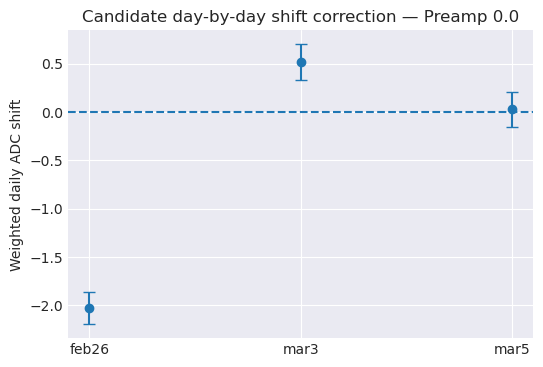

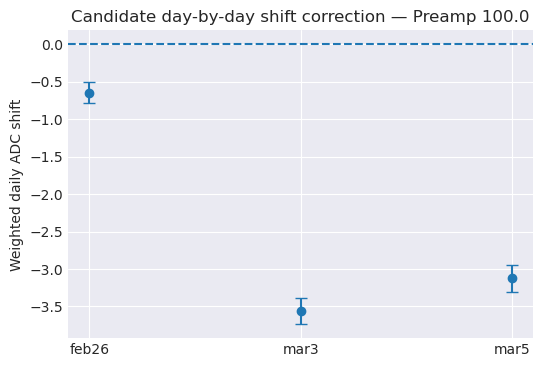

In [37]:
# -----------------------------
# PLOT CANDIDATE DAILY SHIFTS
# -----------------------------

for preamp_value in sorted(daily_shift_table["preamp"].unique()):
    sub = daily_shift_table[daily_shift_table["preamp"] == preamp_value].copy()

    plt.figure(figsize=(6, 4))
    plt.errorbar(
        sub["day"],
        sub["daily_shift_adc"],
        yerr=sub["daily_shift_adc_err"],
        fmt="o",
        capsize=4
    )
    plt.axhline(0, linestyle="--")
    plt.ylabel("Weighted daily ADC shift")
    plt.title(f"Candidate day-by-day shift correction — Preamp {preamp_value}")
    plt.show()

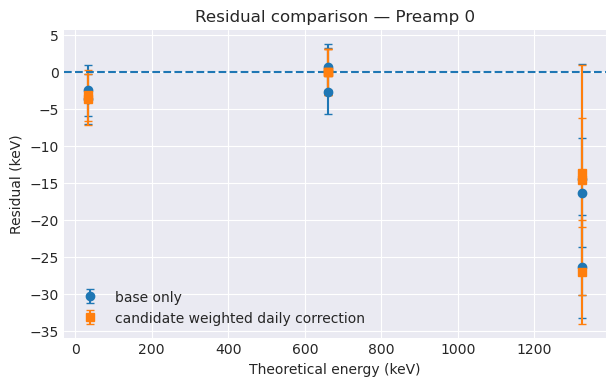

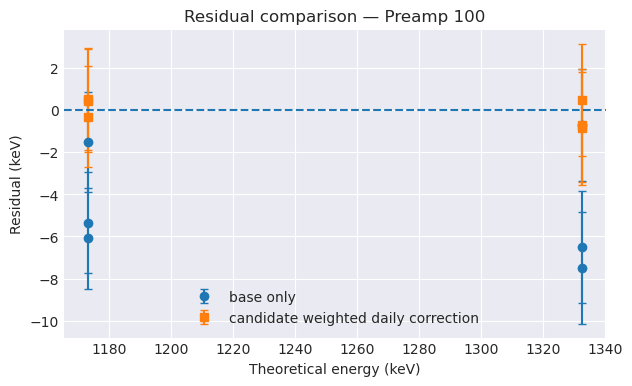

In [38]:
# -----------------------------
# PLOT BEFORE/AFTER RESIDUALS
# -----------------------------

for preamp_value in sorted(daily_eval["preamp"].dropna().unique()):
    sub = daily_eval[daily_eval["preamp"] == preamp_value].copy()

    plt.figure(figsize=(7, 4))
    plt.errorbar(
        sub["theoretical_energy_keV"],
        sub["resid_base_keV"],
        yerr=sub["resid_base_err_keV"],
        fmt="o",
        capsize=3,
        label="base only"
    )
    plt.errorbar(
        sub["theoretical_energy_keV"],
        sub["resid_shift_keV"],
        yerr=sub["resid_shift_err_keV"],
        fmt="s",
        capsize=3,
        label="candidate weighted daily correction"
    )
    plt.axhline(0, linestyle="--")
    plt.xlabel("Theoretical energy (keV)")
    plt.ylabel("Residual (keV)")
    plt.title(f"Residual comparison — Preamp {int(preamp_value)}")
    plt.legend()
    plt.show()

In [39]:
# -----------------------------
# COMPACT INTERPRETIVE TABLE
# -----------------------------

interpret_rows = []

for preamp_value in sorted(daily_eval["preamp"].dropna().unique()):
    sub = daily_eval[daily_eval["preamp"] == preamp_value].copy()

    interpret_rows.append({
        "preamp": int(preamp_value),
        "n_points": len(sub),
        "global_wrss_base": np.sum(sub["pull_base"]**2),
        "global_wrss_shift": np.sum(sub["pull_shift"]**2),
        "global_rms_base_keV": np.sqrt(np.mean(sub["resid_base_keV"]**2)),
        "global_rms_shift_keV": np.sqrt(np.mean(sub["resid_shift_keV"]**2))
    })

interpret_df = pd.DataFrame(interpret_rows).sort_values("preamp")
display(interpret_df)

,preamp,n_points,global_wrss_base,global_wrss_shift,global_rms_base_keV,global_rms_shift_keV
0,0,8,22.415700,21.211683,12.246514,12.008727
1,100,6,25.839206,0.308300,5.274779,0.590140


In [40]:
# -----------------------------
# CHI-SQUARE COMPARISON BY DAY / PREAMP
# -----------------------------

chisq_rows = []

for (day, preamp), sub in daily_eval.groupby(["day", "preamp"]):
    chi2_base = np.sum(sub["pull_base"]**2)
    chi2_shift = np.sum(sub["pull_shift"]**2)

    n = len(sub)

    # Both models use the same base curve, but the shift model estimates
    # one additional day-specific parameter Delta_d from that day's data.
    dof_base = max(n, 1)
    dof_shift = max(n - 1, 1)

    redchi2_base = chi2_base / dof_base
    redchi2_shift = chi2_shift / dof_shift

    chisq_rows.append({
        "day": day,
        "preamp": int(preamp),
        "n_points": n,
        "chi2_base": chi2_base,
        "dof_base": dof_base,
        "redchi2_base": redchi2_base,
        "chi2_shift": chi2_shift,
        "dof_shift": dof_shift,
        "redchi2_shift": redchi2_shift,
        "delta_chi2": chi2_shift - chi2_base,
        "delta_redchi2": redchi2_shift - redchi2_base
    })

chisq_day_preamp = pd.DataFrame(chisq_rows).sort_values(["preamp", "day"])

print("Chi-square comparison by day and preamp:")
display(chisq_day_preamp)

Chi-square comparison by day and preamp:


,day,preamp,n_points,chi2_base,dof_base,redchi2_base,chi2_shift,dof_shift,redchi2_shift,delta_chi2,delta_redchi2
0,feb26,0,2,5.685573,2,2.842786,3.448902,1,3.448902,-2.236671,0.606115
2,mar3,0,3,14.705693,3,4.901898,15.716738,2,7.858369,1.011045,2.956471
4,mar5,0,3,2.024435,3,0.674812,2.046043,2,1.023022,0.021609,0.348210
1,feb26,100,2,0.473923,2,0.236962,0.051575,1,0.051575,-0.422348,-0.185386
3,mar3,100,2,14.363195,2,7.181597,0.151937,1,0.151937,-14.211258,-7.029661
5,mar5,100,2,11.002089,2,5.501044,0.104788,1,0.104788,-10.897301,-5.396256


In [41]:
# -----------------------------
# GLOBAL CHI-SQUARE COMPARISON BY PREAMP
# -----------------------------

global_chisq_rows = []

for preamp_value, sub in daily_eval.groupby("preamp"):
    chi2_base = np.sum(sub["pull_base"]**2)
    chi2_shift = np.sum(sub["pull_shift"]**2)

    n = len(sub)

    # Number of unique day-specific shift parameters used for this preamp
    n_day_params = shift_df[shift_df["preamp"] == preamp_value]["day"].nunique()

    dof_base = max(n, 1)
    dof_shift = max(n - n_day_params, 1)

    redchi2_base = chi2_base / dof_base
    redchi2_shift = chi2_shift / dof_shift

    global_chisq_rows.append({
        "preamp": int(preamp_value),
        "n_points": n,
        "n_day_shift_params": n_day_params,
        "chi2_base": chi2_base,
        "dof_base": dof_base,
        "redchi2_base": redchi2_base,
        "chi2_shift": chi2_shift,
        "dof_shift": dof_shift,
        "redchi2_shift": redchi2_shift,
        "delta_chi2": chi2_shift - chi2_base,
        "delta_redchi2": redchi2_shift - redchi2_base
    })

global_chisq_df = pd.DataFrame(global_chisq_rows).sort_values("preamp")

print("Global chi-square comparison by preamp:")
display(global_chisq_df)

Global chi-square comparison by preamp:


,preamp,n_points,n_day_shift_params,chi2_base,dof_base,redchi2_base,chi2_shift,dof_shift,redchi2_shift,delta_chi2,delta_redchi2
0,0,8,3,22.415700,8,2.801963,21.211683,5,4.242337,-1.204018,1.440374
1,100,6,3,25.839206,6,4.306534,0.308300,3,0.102767,-25.530907,-4.203768


In [42]:
# -----------------------------
# CHI-SQUARE COMPARISON BY QUALITY TIER
# -----------------------------

tier_chisq_rows = []

for tier, sub in daily_eval.groupby("quality_tier"):
    chi2_base = np.sum(sub["pull_base"]**2)
    chi2_shift = np.sum(sub["pull_shift"]**2)

    n = len(sub)

    tier_chisq_rows.append({
        "quality_tier": tier,
        "n_points": n,
        "chi2_base": chi2_base,
        "chi2_shift": chi2_shift,
        "redchi2_base_naive": chi2_base / max(n, 1),
        "redchi2_shift_naive": chi2_shift / max(n, 1)
    })

tier_chisq_df = pd.DataFrame(tier_chisq_rows).sort_values("quality_tier")

print("Chi-square comparison by peak-quality tier:")
display(tier_chisq_df)

Chi-square comparison by peak-quality tier:


,quality_tier,n_points,chi2_base,chi2_shift,redchi2_base_naive,redchi2_shift_naive
0,primary,9,26.630126,0.308300,2.958903,0.034256
1,secondary,5,21.624780,21.211683,4.324956,4.242337


In [43]:
# -----------------------------
# CHI-SQUARE P-VALUE COMPARISON
# -----------------------------

from scipy.stats import chi2

pval_rows = []

for (day, preamp), sub in daily_eval.groupby(["day", "preamp"]):
    chi2_base = np.sum(sub["pull_base"]**2)
    chi2_shift = np.sum(sub["pull_shift"]**2)

    n = len(sub)
    dof_base = max(n, 1)
    dof_shift = max(n - 1, 1)

    p_base = chi2.sf(chi2_base, dof_base)
    p_shift = chi2.sf(chi2_shift, dof_shift)

    pval_rows.append({
        "day": day,
        "preamp": int(preamp),
        "n_points": n,
        "chi2_base": chi2_base,
        "dof_base": dof_base,
        "p_base": p_base,
        "chi2_shift": chi2_shift,
        "dof_shift": dof_shift,
        "p_shift": p_shift
    })

pval_df = pd.DataFrame(pval_rows).sort_values(["preamp", "day"])

print("Chi-square p-value comparison by day and preamp:")
display(pval_df)

Chi-square p-value comparison by day and preamp:


,day,preamp,n_points,chi2_base,dof_base,p_base,chi2_shift,dof_shift,p_shift
0,feb26,0,2,5.685573,2,0.058263,3.448902,1,0.063294
2,mar3,0,3,14.705693,3,0.002086,15.716738,2,0.000387
4,mar5,0,3,2.024435,3,0.567351,2.046043,2,0.359507
1,feb26,100,2,0.473923,2,0.789022,0.051575,1,0.820345
3,mar3,100,2,14.363195,2,0.000760,0.151937,1,0.696691
5,mar5,100,2,11.002089,2,0.004083,0.104788,1,0.746158
